In [ ]:
import glob
import json
import os.path

from sympy import farthest_points

config_path = '../../../questions/question.json'
with open(config_path) as f:
    data = json.load(f)
    
BASE_DIR = data["user_dir"]

for dataset in data["datasets"]:
    dataset_dir = os.path.join(BASE_DIR, data["datasets"][dataset]["sub_dir"])
    # read the all the json files under dataset_dir
    # List all JSON files in the directory
    json_files = glob.glob(os.path.join(dataset_dir, '*.json'))
    data["datasets"][dataset]["number"] = len(json_files)
    data["datasets"][dataset]["list"] = json_files
        
    
with open(config_path, 'w') as f:
    # Use json.dump() to write JSON data
    json.dump(data, f, indent=4)   
    
    

In [10]:
from src.attentivetrim.tool.eval_with_grd_local import cosine_distance
from sentence_transformers import SentenceTransformer
import json

model = 'gpt-4-1106-preview'
config_path = '../../../questions/question.json'
with open(config_path) as f:
    data = json.load(f)
    
# dataset = "notice"
dataset = "paper"
file_list = data["datasets"][dataset]["list"]
questions = data["query"][f'{dataset.upper()}_QUESTIONS']
if "cos_sim" not in data:
    data["cos_sim"] = {}
# 2d array to store the cos_sim as len(questions) x len(questions)
data["cos_sim"][dataset] = [[0.0 for i in range(len(questions))] for j in range(len(questions))]

# Load a model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Define two sample inputs
input_a = "The quick brown fox jumps over the lazy dog."
input_b = "A fast brown fox leaps over a lazy dog."
# iterate over all the question pairs
for i in range(len(questions)):
    for j in range(len(questions)):
        print(f"Processing question pair: {questions[i]} and {questions[j]} on dataset: {dataset}")
        input_a = questions[i]
        input_b = questions[j]
        # Calculate cosine similarity
        similarity = cosine_distance(input_a, input_b, embedding_model)
        data["cos_sim"][dataset][i][j] = int(similarity*100)
        print(f"Cosine Similarity: {similarity}")
with open(config_path, 'w') as f:
    # Use json.dump() to write JSON data
    json.dump(data, f, indent=4)
data["cos_sim"][dataset]

/Users/chunwei/PycharmProjects/attentivetrim/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Processing question pair: What is the title of the paper? and What is the title of the paper? on dataset: paper
Cosine Similarity: 1.0000001192092896
Processing question pair: What is the title of the paper? and What is the authors of the paper? on dataset: paper
Cosine Similarity: 0.735934853553772
Processing question pair: What is the title of the paper? and What is the publication year of the paper? on dataset: paper
Cosine Similarity: 0.6568883657455444
Processing question pair: What is the title of the paper? and What is the type of contribution? on dataset: paper
Cosine Similarity: 0.3534243106842041
Processing question pair: What is the title of the paper? and What is the domain of this paper? on dataset: paper
Cosine Similarity: 0.6466960906982422
Processing question pair: What is the title of the paper? and What is the type of study of this paper? on dataset: paper
Cosine Similarity: 0.6557592153549194
Processing question pair: What is the title of the paper? and What is the v

[[100, 73, 65, 35, 64, 65, 65, 18, 30, 16, 39, 65, 69],
 [73, 100, 63, 43, 55, 62, 63, 19, 33, 26, 68, 63, 71],
 [65, 63, 99, 29, 52, 50, 64, 19, 23, 18, 48, 92, 56],
 [35, 43, 29, 100, 22, 39, 30, 15, 23, 32, 38, 32, 61],
 [64, 55, 52, 22, 100, 61, 61, 26, 26, 16, 26, 56, 49],
 [65, 62, 50, 39, 61, 100, 54, 23, 40, 45, 35, 50, 63],
 [65, 63, 64, 30, 61, 54, 99, 26, 24, 26, 43, 82, 59],
 [18, 19, 19, 15, 26, 23, 26, 100, 20, 14, 7, 22, 19],
 [30, 33, 23, 23, 26, 40, 24, 20, 100, 22, 18, 19, 36],
 [16, 26, 18, 32, 16, 45, 26, 14, 22, 100, 34, 25, 24],
 [39, 68, 48, 38, 26, 35, 43, 7, 18, 34, 99, 50, 43],
 [65, 63, 92, 32, 56, 50, 82, 22, 19, 25, 50, 100, 58],
 [69, 71, 56, 61, 49, 63, 59, 19, 36, 24, 43, 58, 100]]

In [11]:
import json
import os

from src.attentivetrim.sample.get_grd_batch import run_grd_batch

model = 'gpt-4-1106-preview'
config_path = '../../../questions/question.json'
with open(config_path) as f:
    data = json.load(f)
    
# dataset = "notice"
dataset = "paper"
file_list = data["datasets"][dataset]["list"]
questions = data["query"][f'{dataset.upper()}_QUESTIONS'][:2]

for question in questions:
    print(f"Processing question: {question} on dataset: {dataset}")
    grd_output_file = f"../../../grd/{dataset}_{question}.json"
    json_obj = run_grd_batch(file_list, question, model=model)
    json_obj["model"] = model
    json_string = json.dumps(json_obj, indent=4)
    with open(grd_output_file, 'w') as f:
        f.write(json_string)

Processing question: What is the title of the paper? on dataset: paper


 		You are using the client GPT3, which will be removed in DSPy 2.6.
 		Changing the client is straightforward and will let you use new features (Adapters) that improve the consistency of LM outputs, especially when using chat LMs. 

 		Learn more about the changes and how to migrate at
 		https://github.com/stanfordnlp/dspy/blob/main/examples/migration.ipynb


Duration: 4.691495180130005
file: /Users/chunwei/research/ZenDB/raw_data/paper/Entangled with Numbers: Quantified Self and Others in a Team-Based Online Game_pm.json  groundtruth:  Entangled with Numbers: Quantified Self and Others in a Team-Based Online Game  rationale:  produce the answer. We need to locate the title of the paper within the provided context. The title is typically found at the beginning of the paper and is often in a larger or bold font to stand out. In the provided context, the title appears after the publication information and before the authors' names and institutions.
Duration: 2.3722801208496094
file: /Users/chunwei/research/ZenDB/raw_data/paper/MoodLight: Exploring Personal and Social Implications of Ambient Display of Biosensor Data_pm.json  groundtruth:  MoodLight: Exploring Personal and Social Implications of Ambient Display of Biosensor Data  rationale:  produce the answer. We need to locate the title of the paper within the provided context. The title is 

In [12]:
# Get the ground truth location
from src.attentivetrim import best_substring_match
import json

model = 'gpt-4-1106-preview'
config_path = '../../../questions/question.json'
with open(config_path) as f:
    data = json.load(f)
    
# dataset = "notice"
dataset = "paper"
file_list = data["datasets"][dataset]["list"]
questions = data["query"][f'{dataset.upper()}_QUESTIONS'][:2]

for question in questions:
    print(f"Processing question: {question} on dataset: {dataset}")
    with open(f"../../../grd/{dataset}_{question}.json", 'r') as f:
        json_obj = json.loads(f.read())
    for entry in json_obj["files"]:
        file_path = entry["file"]
        query = entry["groundtruth"]
        with open(file_path) as f_in:
            doc_dict = json.load(f_in)
        string = doc_dict["symbols"]
        total_chars = len(string)
        start, end = best_substring_match(query, string)
        entry["total_chars"] = total_chars
        entry["start"] = start
        entry["end"] = end
        entry["substring"] = string[start:end]
        print("file:", file_path, " total_chars: ", total_chars, " start: ", start, " end: ", end)
        print("ground truth: ", query)
        print ("substring: ", string[start:end])
    json_string = json.dumps(json_obj, indent=4)
    with open(f"../../../grd_loc/{dataset}_{question}-location.json", 'w') as f:
        f.write(json_string)
    
    

Processing question: What is the title of the paper? on dataset: paper
grd: Entangled with Numbers: Quantified Self and Others in a Team-Based Online Game
best match: Entangled with Numbers: Quantified Self
and Others in a Team-Based Online Game score: 100 start: 118 end: 196
file: /Users/chunwei/research/ZenDB/raw_data/paper/Entangled with Numbers: Quantified Self and Others in a Team-Based Online Game_pm.json  total_chars:  98366  start:  118  end:  196
ground truth:  Entangled with Numbers: Quantified Self and Others in a Team-Based Online Game
substring:  Entangled with Numbers: Quantified Self
and Others in a Team-Based Online Game
grd: MoodLight: Exploring Personal and Social Implications of Ambient Display of Biosensor Data
best match: MoodLight: Exploring Personal and Social Implications of
Ambient Display of Biosensor Data score: 100 start: 0 end: 90
file: /Users/chunwei/research/ZenDB/raw_data/paper/MoodLight: Exploring Personal and Social Implications of Ambient Display of B

Skipping /Users/chunwei/research/ZenDB/raw_data/paper/Understanding the Adoption of Quantified Self-tracking Wearable Devices in the Organization Environment: An Empirical Case Study_pm.json as it has no groundtruth
Skipping /Users/chunwei/research/ZenDB/raw_data/paper/Understanding the Adoption of Quantified Self-tracking Wearable Devices in the Organization Environment: An Empirical Case Study_pm.json as it has no groundtruth


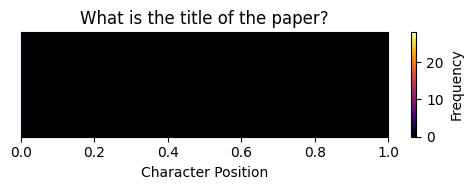

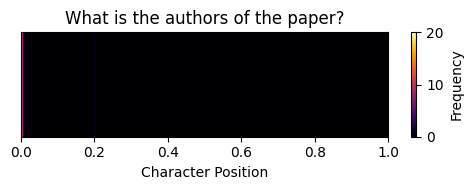

In [13]:
# Get the ground truth heatmap
import json
from src.attentivetrim.sample.get_heatmap import analyze_and_plot_location_data

config_path = '../../../questions/question.json'
with open(config_path) as f:
    data = json.load(f)
    
# dataset = "notice"
dataset = "paper"
file_list = data["datasets"][dataset]["list"]
questions = data["query"][f'{dataset.upper()}_QUESTIONS'][:2]

for question in questions:
    task_file = f"{dataset}_{question}-location.json"
    analyze_and_plot_location_data(task_file)

In [1]:
# 
from src.attentivetrim.sample.get_sample_prediction import run_sample_pred_batch
import os
import json

import dsp
import dspy


dsp.modules.cache_utils.cache_turn_on = False
if 'OPENAI_API_KEY' not in os.environ:
    raise ValueError("OPENAI_API_KEY not found in environment variables")
openai_key = os.environ['OPENAI_API_KEY']
turbo = dspy.OpenAI(model='gpt-4-1106-preview', api_key=openai_key, temperature=0.0)
dspy.settings.configure(lm=turbo)

# Run the model with given budget
config_path = '../../../questions/question.json'

with open(config_path) as f:
    data = json.load(f)
    
# dataset = "notice"
dataset = "paper"
file_list = data["datasets"][dataset]["list"]
questions = data["query"][f'{dataset.upper()}_QUESTIONS']
loc_dir = "../../../grd_loc"
heatmap_dir = "../../../heatmap"
pred_dir = "../../../pred"
budgets = data["budgets"]

dataset_pred_dir = os.path.join(pred_dir, dataset)
if not os.path.exists(dataset_pred_dir):
    os.makedirs(dataset_pred_dir)

for question in questions:
    task_file = f"{dataset}_{question}-location.json"
    # read the whole file list
    with open(f"{loc_dir}/{task_file}", 'r') as f:
        json_obj = json.loads(f.read())
    whole_file_list = [entry["file"] for entry in json_obj["files"]]
    
    # read the heatmap sample file list
    with open(f"{heatmap_dir}/heatmap-{task_file}", 'r') as f:
        heatmap_json_obj = json.loads(f.read())
    sample_file_list = [entry["file"] for entry in heatmap_json_obj["chosen_files"]]
    
    # get the difference and keep the order
    diff_list = []
    for file in whole_file_list:
        if file not in sample_file_list:
            diff_list.append(file)
    
    print("whole_file_list:", len(whole_file_list), "\nsample_file_list:", len(sample_file_list), "\ndiff_list:", len(diff_list))
    

    list_of_files = diff_list
    hist_file = os.path.join(heatmap_dir, f"heatmap-{task_file}")
    for budget in budgets:
        print("question:", question, "hist_file:", hist_file, "budget:", budget)
        results = run_sample_pred_batch(list_of_files, question, hist_file, budget=budget)
        json_string = json.dumps(results, indent=4)
        pred_file = os.path.join(dataset_pred_dir, f"results-{budget}-{task_file}")
        with open(pred_file, 'w') as f:
            f.write(json_string)

whole_file_list: 99 
sample_file_list: 29 
diff_list: 70
question: What is the main contribution of the paper? hist_file: ../../../heatmap/heatmap-paper_What is the main contribution of the paper?-location.json budget: 0.002
best_start: 108 best_end: 109
leading_zeros: 0 trailing_zeros: 0 half_zeros: 0
start: 108 end: 110 index_range: 1000.0
start ratio: 0.108 end ratio: 0.11
character start: 10623 end: 10820
sample size: 197
file: /Users/chunwei/research/ZenDB/raw_data/paper/Entangled with Numbers: Quantified Self and Others in a Team-Based Online Game_pm.json  result: None
character start: 6369 end: 6487
sample size: 118
file: /Users/chunwei/research/ZenDB/raw_data/paper/MoodLight: Exploring Personal and Social Implications of Ambient Display of Biosensor Data_pm.json  result: None
character start: 6037 end: 6149
sample size: 112
file: /Users/chunwei/research/ZenDB/raw_data/paper/Pass the Ball: Enforced Turn-Taking in Activity Tracking_pm.json  result: None
character start: 8610 end:

In [2]:
from src.attentivetrim.tool.diverse.eval_with_grd_local_diverse import evaluate_rouge_results
from src.attentivetrim.tool.diverse.eval_with_grd_diverse import evaluate_results
from src.attentivetrim.sample.get_sample_prediction import run_sample_pred_batch
import os
import json
import dsp
import dspy


dsp.modules.cache_utils.cache_turn_on = False
if 'OPENAI_API_KEY' not in os.environ:
    raise ValueError("OPENAI_API_KEY not found in environment variables")
openai_key = os.environ['OPENAI_API_KEY']
turbo = dspy.OpenAI(model='gpt-4-1106-preview', api_key=openai_key, temperature=0.0)
dspy.settings.configure(lm=turbo)

# Run the model with given budget
config_path = '../../../questions/question.json'

with open(config_path) as f:
    data = json.load(f)

dataset = "paper"
# dataset = "notice"
file_list = data["datasets"][dataset]["list"]
questions = data["query"][f'{dataset.upper()}_QUESTIONS']
loc_dir = "../../../grd_loc"
heatmap_dir = "../../../heatmap"
pred_dir = "../../../pred"
acc_gpt_dir = "../../../acc/gpt"
acc_rouge_dir = "../../../acc/rouge"
budgets = data["budgets"]

dataset_pred_dir = os.path.join(pred_dir, dataset)
if not os.path.exists(dataset_pred_dir):
    os.makedirs(dataset_pred_dir)

for question in questions:
    task_file = f"{dataset}_{question}-location.json"
    
    for budget in budgets:
        print("question:", question, "budget:", budget)
        results_file = os.path.join(dataset_pred_dir, f"results-{budget}-{task_file}")
        groundtruth_file = os.path.join(loc_dir, task_file)
        acc_gpt_file = os.path.join(acc_gpt_dir, f"acc-{budget}-{task_file}".replace(".json", "-acc.json"))
        acc_rouge_file = os.path.join(acc_rouge_dir, f"acc-{budget}-{task_file}".replace(".json", "-acc.json"))
        evaluate_results(results_file, groundtruth_file, acc_gpt_file)
        evaluate_rouge_results(results_file, groundtruth_file, acc_rouge_file)


question: What is the main contribution of the paper? budget: 0.002
Total matches: 0 out of 70
Total avg budget: 0.0


/Users/chunwei/PycharmProjects/attentivetrim/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/chunwei/PycharmProjects/attentivetrim/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Total matches: 0 out of 70
